In [17]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim, output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim, output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim, output_dim, u)
        else:
            raise ValueError("Unknown model")
    return df

In [18]:
import re
import csv
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

# =================================================
# 事前定義: params 辞書（ここを唯一の正とする）
# =================================================
PARAMS_MAP = {
    "ncp_u64_best": 28487,
    "ncp_u128_best": 97927,
    "ncp_u256_best": 359687,
    "bc-pure": 1077255,
    "bc-rnn-pure": 1956407,
}

# CSVファイル名 → notebook内で使う model 名
MODEL_ALIAS = {
    "ncp_u64": "ncp_u64_best",
    "ncp_u128": "ncp_u128_best",
    "ncp_u256": "ncp_u256_best",
    "mlp": "bc-pure",
    "rnn": "bc-rnn-pure",
}


def _safe_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


# -------------------------------------------------
# CSV を列ズレ耐性付きで読む
# -------------------------------------------------
def robust_read_csv(path: str) -> pd.DataFrame:
    with open(path, "r") as f:
        lines = [ln.rstrip("\n") for ln in f if ln.strip()]

    if not lines:
        return pd.DataFrame()

    header = next(csv.reader([lines[0]]))
    ncols = len(header)

    rows = []
    for ln in lines[1:]:
        fields = next(csv.reader([ln]))

        if len(fields) > ncols:
            extra = len(fields) - ncols
            name = ",".join(fields[: extra + 1])
            rest = fields[extra + 1 :]
            fields = [name] + rest
        elif len(fields) < ncols:
            fields = fields + [None] * (ncols - len(fields))

        rows.append(fields)

    df = pd.DataFrame(rows, columns=header)

    # 列名を正規化（大文字小文字・空白・ハイフン差異の吸収）
    df.columns = [
        str(c).strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns
    ]

    return df


# -------------------------------------------------
# name 解析系
# -------------------------------------------------
def extract_success_from_name(name: str) -> float:
    m = re.search(r"(?:^|[_-])success[_-]([0-9]*\.?[0-9]+)", str(name))
    return float(m.group(1)) if m else np.nan


def extract_seed_last(name: str) -> float:
    seeds = re.findall(r"(?:^|[_-])seed(\d+)", str(name))
    return float(seeds[-1]) if seeds else np.nan


# -------------------------------------------------
# 単一 CSV → top-k 平均（＋デバッグ用に top-k の内訳も返せる）
# -------------------------------------------------
def get_topk_avg_score(
    df: pd.DataFrame,
    seed_min: int = 1,
    seed_max: int = 20,
    model_name: str | None = None,
    top_k: int = 10,
    rank_by: str = "success_rate",
    return_details: bool = False,
 ) -> pd.DataFrame | tuple[pd.DataFrame, pd.DataFrame]:

    df = df.copy()

    if "name" not in df.columns:
        raise KeyError("'name' column not found")

    df = _safe_numeric(df, ["success_rate", "return"])

    if rank_by not in df.columns:
        raise KeyError(f"'{rank_by}' column not found")

    # seed 抽出
    df["seed"] = df["name"].map(extract_seed_last)

    # seed が入っていないCSV（mlp/rnn等）は、行IDを擬似seedとして top-k を取る
    has_real_seed = df["seed"].notna().any()
    if has_real_seed:
        df = df[df["seed"].between(seed_min, seed_max, inclusive="both")]
    else:
        df["seed"] = np.arange(1, len(df) + 1, dtype=float)

    # rank_by 欠損除去
    df = df[df[rank_by].notna()]

    # model 名（単一CSVとして固定するのが安全）
    df["model"] = model_name if model_name else "unknown"

    # seed ごとに最大 success_rate を取る（同一seedに複数行ある場合に最大を採用）
    df_seed = (
        df.groupby(["model", "seed"], as_index=False)
        .agg(
            success_rate_max=("success_rate", "max"),
            return_mean=("return", "mean"),
        )
    )

    # top-k seed
    df_seed = df_seed.sort_values(["model", "success_rate_max"], ascending=[True, False])
    df_top = df_seed.groupby("model", as_index=False).head(top_k).copy()
    df_top["rank"] = df_top.groupby("model").cumcount() + 1

    # model 平均
    df_avg = (
        df_top.groupby("model")
        .agg(
            success_rate=("success_rate_max", "mean"),
            success_rate_std=("success_rate_max", "std"),
            return_avg=("return_mean", "mean"),
            n_seeds=("seed", "nunique"),
            selected_seeds=("seed", lambda s: sorted(map(int, s.tolist()))),
        )
        .reset_index()
    )

    if return_details:
        return df_avg, df_top
    return df_avg


# -------------------------------------------------
# 複数 CSV
# -------------------------------------------------
def aggregate_multiple_csvs(
    csv_files: list[str],
    seed_min: int = 1,
    seed_max: int = 20,
    top_k: int = 10,
    rank_by: str = "success_rate",
    return_details: bool = False,
) -> pd.DataFrame | tuple[pd.DataFrame, pd.DataFrame]:

    results = []
    details = []

    for path in csv_files:
        df = robust_read_csv(path)
        if df.empty:
            continue

        stem = Path(path).stem
        model_name = MODEL_ALIAS.get(stem, stem)

        df_avg, df_top = get_topk_avg_score(
            df,
            seed_min=seed_min,
            seed_max=seed_max,
            model_name=model_name,
            top_k=top_k,
            rank_by=rank_by,
            return_details=True,
        )

        df_avg["source_csv"] = Path(path).name
        results.append(df_avg)

        df_top["source_csv"] = Path(path).name
        details.append(df_top)

    if not results:
        empty = pd.DataFrame()
        return (empty, empty) if return_details else empty

    out = pd.concat(results, ignore_index=True)
    out["params"] = out["model"].map(PARAMS_MAP)

    detail_df = pd.concat(details, ignore_index=True) if details else pd.DataFrame()
    return (out, detail_df) if return_details else out


# -------------------------------------------------
# 使い方（このセルで df_all を作る。下のセルは df_all を参照する）
# -------------------------------------------------
csv_files = [
    "/work/robomimic/csv/result/baseline/lift/ncp_u64.csv",
    "/work/robomimic/csv/result/baseline/lift/ncp_u128.csv",
    "/work/robomimic/csv/result/baseline/lift/ncp_u256.csv",
    "/work/robomimic/csv/result/baseline/lift/mlp.csv",
    "/work/robomimic/csv/result/baseline/lift/rnn.csv",
]

df_all, df_top_detail = aggregate_multiple_csvs(
    csv_files,
    top_k=10,
    rank_by="success_rate",  # "return" に切り替えてもOK
    return_details=True,
 )

# 表示は短く（切れ対策）
df_summary = df_all[["model", "success_rate", "success_rate_std", "params", "n_seeds"]].sort_values("params")
display(df_summary)

# =================================================
# デバッグ: 各モデルで選ばれた success_rate top-10 を表示
# （平均が高すぎる原因の切り分け用）
# =================================================
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

if df_top_detail is not None and (not df_top_detail.empty):
    # 10個が横に並ぶ形（モデル×rank）も出す
    pivot = df_top_detail.pivot(index="model", columns="rank", values="success_rate_max")
    display(pivot)
else:
    print("df_top_detail is empty")

,model,success_rate,success_rate_std,params,n_seeds
0,ncp_u64_best,0.985,0.010801,28487,10
1,ncp_u128_best,0.990,0.008165,97927,10
2,ncp_u256_best,0.995,0.005270,359687,10
3,bc-pure,0.992,0.007888,1077255,10
4,bc-rnn-pure,1.000,0.000000,1956407,10


rank,1,2,3,4,5,6,7,8,9,10
model,,,,,,,,,,
bc-pure,1.0,1.0,1.00,1.00,0.99,0.99,0.99,0.99,0.98,0.98
bc-rnn-pure,1.0,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
ncp_u128_best,1.0,1.0,1.00,0.99,0.99,0.99,0.99,0.98,0.98,0.98
ncp_u256_best,1.0,1.0,1.00,1.00,1.00,0.99,0.99,0.99,0.99,0.99
ncp_u64_best,1.0,1.0,0.99,0.99,0.99,0.98,0.98,0.98,0.97,0.97


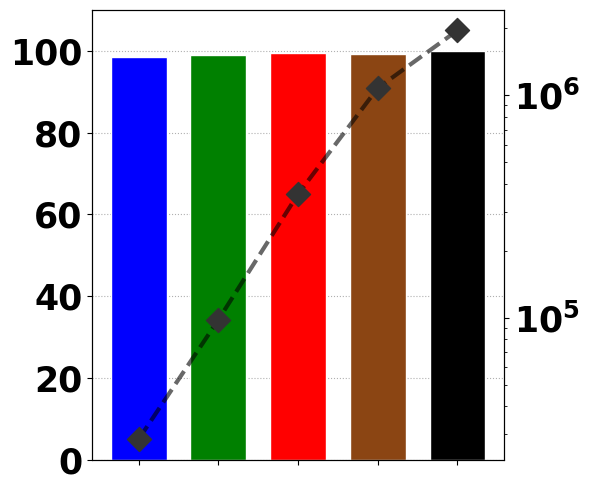

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. スタイル設定 ---
plt.rcParams.update({
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

# --- 2. 色定義 ---
explicit_color = {
    "ncp_u64_best":  "blue",
    "ncp_u128_best": "green",
    "ncp_u256_best": "red",
    "bc-pure":       "#8B4513",
    "bc-rnn-pure":   "#000000",
}
default_color = "#d9d9d9"

def get_color(model_name):
    return explicit_color.get(model_name, default_color)

# --- 3. データ（上のセルで作った df_all をそのまま使う） ---
datasets = {
    "Lift": df_all,
}

model_order = [
    "ncp_u64_best",
    "ncp_u128_best",
    "ncp_u256_best",
    "bc-pure",
    "bc-rnn-pure",
]

# --- 4. プロット ---
def plot_dual_axis_bar():
    fig, axes = plt.subplots(figsize=(6,5))
    if len(datasets) == 1:
        axes = [axes]

    for i, (ax1, (task_name, df)) in enumerate(zip(axes, datasets.items())):
        models = [m for m in model_order if m in df["model"].unique()]

        success_rates = []
        params = []
        colors = []

        for m in models:
            sub = df[df["model"] == m]
            success_rates.append(sub["success_rate"].mean() * 100)
            params.append(sub["params"].mean())
            colors.append(get_color(m))

        x = np.arange(len(models))

        # --- 左軸：平均成功率(%) ---
        bars = ax1.bar(
            x, success_rates,
            width=0.7,
            color=colors,
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )
        ax1.set_ylim(0, 110)
        ax1.set_xticks(x)
        ax1.set_xticklabels([""] * len(x))  # 棒の番号は表示しない

        # --- 右軸：パラメータ数 ---
        ax2 = ax1.twinx()

        ax2.plot(
            x, params,
            linestyle="--",
            linewidth=3,
            color="#030303",
            alpha=0.6,
            zorder=2,
        )
        ax2.scatter(
            x, params,
            marker="D",
            s=150,
            color="#333333",
            zorder=3,
        )

        ax2.set_yscale("log")
        ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
        ax2.yaxis.set_minor_locator(
            ticker.LogLocator(base=10, subs=np.arange(1, 10))
        )
        ax2.yaxis.set_major_formatter(
            ticker.LogFormatterMathtext(base=10)
        )
        ax1.grid(
            which="both",
            axis="y",
            linestyle=":",
            alpha=1.0,
            zorder=0
        )

        # =========================
        # 軸数字の表示制御
        # =========================
        if i != 0:
            ax1.set_yticklabels([])
            ax1.tick_params(axis="y", length=0)
            ax1.set_ylabel("")

        if i != len(axes) - 1:
            ax2.set_yticklabels([])
            ax2.tick_params(axis="y", length=0)
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()


# 実行
plot_dual_axis_bar()


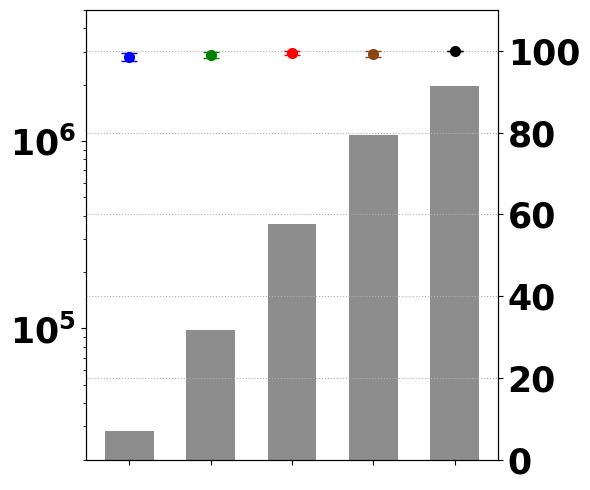

In [20]:
def plot_dual_axis_bar_with_error():
    fig, ax1 = plt.subplots(figsize=(6,5))

    df = datasets["Lift"]
    models = [m for m in model_order if m in df["model"].unique()]

    success_mean = []
    success_std = []
    params = []
    colors = []

    for m in models:
        sub = df[df["model"] == m]
        success_mean.append(sub["success_rate"].values[0] * 100)
        success_std.append(sub["success_rate_std"].values[0] * 100)
        params.append(sub["params"].values[0])
        colors.append(get_color(m))

    x = np.arange(len(models))

    # =========================
    # 左軸：パラメータ数（棒グラフ）
    # =========================
    ax2 = ax1.twinx()
    ax1.bar(
        x, params,
        width=0.6,
        color="#8D8D8D",
        alpha=1.0,
        linewidth=1.5,
        zorder=1,
    )

    ax1.set_yscale("log")
    ax1.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax1.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))

    # グリッドを成功率軸（ax2）に合わせ、データの背面に描画
    ax2.set_axisbelow(True)
    ax2.grid(which="both", axis="y", linestyle=":", alpha=1.0, zorder=0)

    # =========================
    # 右軸：成功率（モデル色エラーバー）
    # =========================
    for i in range(len(models)):
        ax2.errorbar(
            x[i], success_mean[i],
            yerr=success_std[i],
            fmt="o",
            color=colors[i],
            ecolor=colors[i],
            elinewidth=2.5,
            capsize=6,
            markersize=7,
            zorder=3,
        )

    ax2.set_ylim(0, 110)
    ax1.set_ylim(2e4, 5e6)
    ax1.set_xticks(x)
    ax1.set_xticklabels([""] * len(x))

    plt.tight_layout()
    plt.show()


plot_dual_axis_bar_with_error()


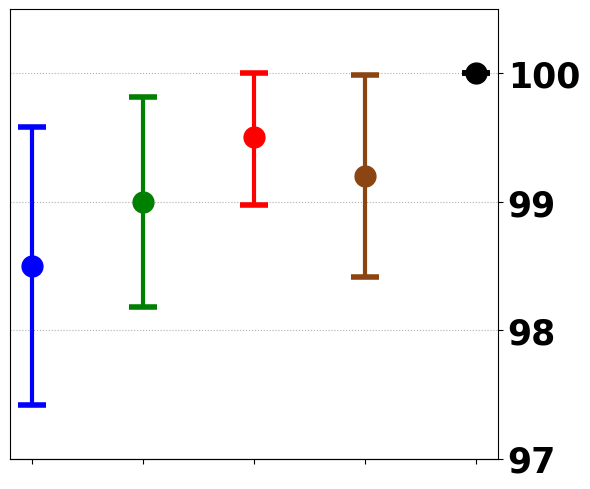

In [21]:
def plot_dual_axis_bar_with_error():
    fig, ax1 = plt.subplots(figsize=(6,5))
    ax2 = ax1.twinx()
    df = datasets["Lift"]
    models = [m for m in model_order if m in df["model"].unique()]

    success_mean = []
    success_std = []
    params = []
    colors = []

    for m in models:
        sub = df[df["model"] == m]
        success_mean.append(sub["success_rate"].values[0] * 100)
        success_std.append(sub["success_rate_std"].values[0] * 100)
        params.append(sub["params"].values[0])
        colors.append(get_color(m))

    x = np.arange(len(models))

    # =========================
    # 左軸：成功率（モデル色エラーバー）
    # =========================
    upper_cap = 100.0
    for i in range(len(models)):
        mean = success_mean[i]
        std = success_std[i]

        # 下側はそのまま
        lower_err = std

        # 上側は 100 を超えないように制限
        upper_err = min(std, upper_cap - mean)

        ax2.errorbar(
            x[i], mean,
            yerr=[[lower_err], [upper_err]],  # ← 非対称エラーバー
            fmt="o",
            color=colors[i],
            ecolor=colors[i],
            elinewidth=3,
            capsize=10,
            capthick=4,
            markersize=15,
            zorder=3,
        )

    ax2.set_ylim(97, 100.5)
    ax2.set_yticks([97, 98, 99, 100])
    
    ax2.spines["top"].set_visible(False)
    ax2.set_xticks(x)
    ax2.set_xticklabels([""] * len(x))

    ax2.grid(which="both", axis="y", linestyle=":", alpha=1.0, zorder=-3)

    ax1.set_yticks([])
    ax1.set_ylabel("")
    ax1.spines["left"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.tick_params(left=False)
    
    plt.tight_layout()
    plt.show()


plot_dual_axis_bar_with_error()


In [22]:
# Canタスク
csv_files = [
    "/work/robomimic/csv/result/baseline/can/ncp_u64.csv",
    "/work/robomimic/csv/result/baseline/can/ncp_u128.csv",
    "/work/robomimic/csv/result/baseline/can/ncp_u256.csv",
    "/work/robomimic/csv/result/baseline/can/mlp.csv",
    "/work/robomimic/csv/result/baseline/can/rnn.csv",
]

df_all, df_top_detail = aggregate_multiple_csvs(
    csv_files,
    top_k=5,
    rank_by="success_rate",  # "return" に切り替えてもOK
    return_details=True,
 )

# 表示は短く（切れ対策）
df_summary = df_all[["model", "success_rate", "params", "n_seeds"]].sort_values("params")
display(df_summary)

# =================================================
# デバッグ: 各モデルで選ばれた success_rate top-10 を表示
# （平均が高すぎる原因の切り分け用）
# =================================================
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

if df_top_detail is not None and (not df_top_detail.empty):
    # 10個が横に並ぶ形（モデル×rank）も出す
    pivot = df_top_detail.pivot(index="model", columns="rank", values="success_rate_max")
    display(pivot)
else:
    print("df_top_detail is empty")

FileNotFoundError: [Errno 2] No such file or directory: '/work/robomimic/csv/result/baseline/can/ncp_u64.csv'

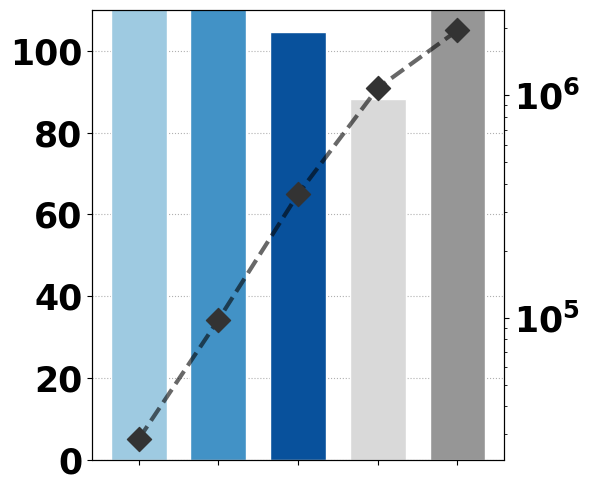

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. スタイル設定 ---
plt.rcParams.update({
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

# --- 2. 色定義 ---
explicit_color = {
    "ncp_u64_best":  "#9ecae1",
    "ncp_u128_best": "#4292c6",
    "ncp_u256_best": "#08519c",
    "bc-pure":       "#d9d9d9",
    "bc-rnn-pure":   "#969696",
}
default_color = "#d9d9d9"

def get_color(model_name):
    return explicit_color.get(model_name, default_color)

# --- 3. データ（上のセルで作った df_all をそのまま使う） ---
datasets = {
    "Lift": df_all,
}

model_order = [
    "ncp_u64_best",
    "ncp_u128_best",
    "ncp_u256_best",
    "bc-pure",
    "bc-rnn-pure",
]

# --- 4. プロット ---
def plot_dual_axis_bar():
    fig, axes = plt.subplots(figsize=(6,5))
    if len(datasets) == 1:
        axes = [axes]

    for i, (ax1, (task_name, df)) in enumerate(zip(axes, datasets.items())):
        models = [m for m in model_order if m in df["model"].unique()]

        success_rates = []
        params = []
        colors = []

        for m in models:
            sub = df[df["model"] == m]
            success_rates.append(sub["success_rate"].mean() * 100)
            params.append(sub["params"].mean())
            colors.append(get_color(m))

        x = np.arange(len(models))

        # --- 左軸：平均成功率(%) ---
        bars = ax1.bar(
            x, success_rates,
            width=0.7,
            color=colors,
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )
        ax1.set_ylim(0, 110)
        ax1.set_xticks(x)
        ax1.set_xticklabels([""] * len(x))  # 棒の番号は表示しない

        # --- 右軸：パラメータ数 ---
        ax2 = ax1.twinx()

        ax2.plot(
            x, params,
            linestyle="--",
            linewidth=3,
            color="#030303",
            alpha=0.6,
            zorder=2,
        )
        ax2.scatter(
            x, params,
            marker="D",
            s=150,
            color="#333333",
            zorder=3,
        )

        ax2.set_yscale("log")
        ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
        ax2.yaxis.set_minor_locator(
            ticker.LogLocator(base=10, subs=np.arange(1, 10))
        )
        ax2.yaxis.set_major_formatter(
            ticker.LogFormatterMathtext(base=10)
        )
        ax1.grid(
            which="both",
            axis="y",
            linestyle=":",
            alpha=1.0,
            zorder=0
        )

        # =========================
        # 軸数字の表示制御
        # =========================
        if i != 0:
            ax1.set_yticklabels([])
            ax1.tick_params(axis="y", length=0)
            ax1.set_ylabel("")

        if i != len(axes) - 1:
            ax2.set_yticklabels([])
            ax2.tick_params(axis="y", length=0)
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()


# 実行
plot_dual_axis_bar()


In [ ]:
# Canタスク
csv_files = [
    "/work/robomimic/csv/result/baseline/square/ncp_u64.csv",
    "/work/robomimic/csv/result/baseline/square/ncp_u128.csv",
    "/work/robomimic/csv/result/baseline/square/ncp_u256.csv",
    "/work/robomimic/csv/result/baseline/square/mlp.csv",
    "/work/robomimic/csv/result/baseline/square/rnn.csv",
]

df_all, df_top_detail = aggregate_multiple_csvs(
    csv_files,
    top_k=5,
    rank_by="success_rate",  # "return" に切り替えてもOK
    return_details=True,
 )

# 表示は短く（切れ対策）
df_summary = df_all[["model", "success_rate", "params", "n_seeds"]].sort_values("params")
display(df_summary)

# =================================================
# デバッグ: 各モデルで選ばれた success_rate top-10 を表示
# （平均が高すぎる原因の切り分け用）
# =================================================
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

if df_top_detail is not None and (not df_top_detail.empty):
    # 10個が横に並ぶ形（モデル×rank）も出す
    pivot = df_top_detail.pivot(index="model", columns="rank", values="success_rate_max")
    display(pivot)
else:
    print("df_top_detail is empty")

,model,success_rate,params,n_seeds
0,ncp_u64_best,4.558799,28487,3
1,ncp_u128_best,1.355979,97927,3
2,ncp_u256_best,1.042837,359687,3
3,bc-pure,0.875822,1077255,3
4,bc-rnn-pure,1.152379,1956407,3


rank,1,2,3
model,,,
bc-pure,0.881986,0.875224,0.870254
bc-rnn-pure,1.154957,1.152096,1.150086
ncp_u128_best,1.363279,1.359129,1.345529
ncp_u256_best,1.049781,1.041684,1.037046
ncp_u64_best,4.733466,4.570138,4.372794


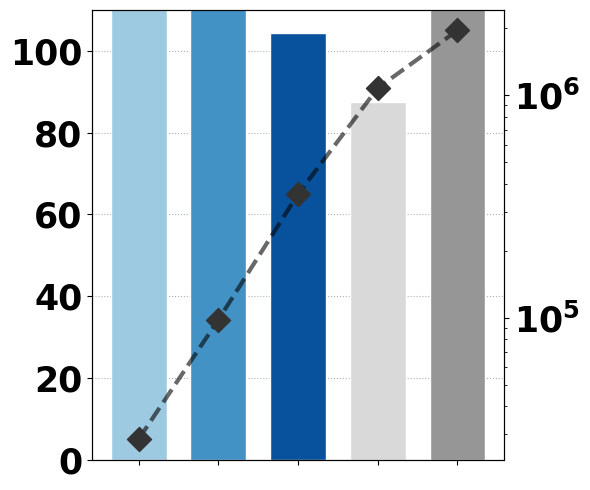

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- 1. スタイル設定 ---
plt.rcParams.update({
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

# --- 2. 色定義 ---
explicit_color = {
    "ncp_u64_best":  "#9ecae1",
    "ncp_u128_best": "#4292c6",
    "ncp_u256_best": "#08519c",
    "bc-pure":       "#d9d9d9",
    "bc-rnn-pure":   "#969696",
}
default_color = "#d9d9d9"

def get_color(model_name):
    return explicit_color.get(model_name, default_color)

# --- 3. データ（上のセルで作った df_all をそのまま使う） ---
datasets = {
    "Lift": df_all,
}

model_order = [
    "ncp_u64_best",
    "ncp_u128_best",
    "ncp_u256_best",
    "bc-pure",
    "bc-rnn-pure",
]

# --- 4. プロット ---
def plot_dual_axis_bar():
    fig, axes = plt.subplots(figsize=(6,5))
    if len(datasets) == 1:
        axes = [axes]

    for i, (ax1, (task_name, df)) in enumerate(zip(axes, datasets.items())):
        models = [m for m in model_order if m in df["model"].unique()]

        success_rates = []
        params = []
        colors = []

        for m in models:
            sub = df[df["model"] == m]
            success_rates.append(sub["success_rate"].mean() * 100)
            params.append(sub["params"].mean())
            colors.append(get_color(m))

        x = np.arange(len(models))

        # --- 左軸：平均成功率(%) ---
        bars = ax1.bar(
            x, success_rates,
            width=0.7,
            color=colors,
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )
        ax1.set_ylim(0, 110)
        ax1.set_xticks(x)
        ax1.set_xticklabels([""] * len(x))  # 棒の番号は表示しない

        # --- 右軸：パラメータ数 ---
        ax2 = ax1.twinx()

        ax2.plot(
            x, params,
            linestyle="--",
            linewidth=3,
            color="#030303",
            alpha=0.6,
            zorder=2,
        )
        ax2.scatter(
            x, params,
            marker="D",
            s=150,
            color="#333333",
            zorder=3,
        )

        ax2.set_yscale("log")
        ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
        ax2.yaxis.set_minor_locator(
            ticker.LogLocator(base=10, subs=np.arange(1, 10))
        )
        ax2.yaxis.set_major_formatter(
            ticker.LogFormatterMathtext(base=10)
        )
        ax1.grid(
            which="both",
            axis="y",
            linestyle=":",
            alpha=1.0,
            zorder=0
        )

        # =========================
        # 軸数字の表示制御
        # =========================
        if i != 0:
            ax1.set_yticklabels([])
            ax1.tick_params(axis="y", length=0)
            ax1.set_ylabel("")

        if i != len(axes) - 1:
            ax2.set_yticklabels([])
            ax2.tick_params(axis="y", length=0)
            ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()


# 実行
plot_dual_axis_bar()
